Fingerprinting

This workbook uses a IDL_python bridge to run fingerprinting analysis on seasonal runoff data across New Zealand. It defines functions which read previously created runoff datafiles and setup the data_obs, data_scen, and noise vectors. These vectors are then input into Daithi Stone's gendetec IDL code which returns the regression coefficients for the multiple linear regression problem as follows: data_obs = beta_est * data_scen + residual. 

Results are saved in ~/figures/fingerprinting/beta_est/ if using a single truncation and ""/scan_beta_est/ if depicting a range of truncation options. 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from idlpy import *
from scipy import stats
import statsmodels.api as sm


import seaborn as sns
import cartopy.crs as ccrs

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024
A new version is available: IDL 8.8.3
https://harrisgeospatial.flexnetoperations.com
 


In [51]:
def get_obs_data(season):
    
    if season == 'all':
        
        df_list = []
        for season in ['winter','spring','summer','autumn']:
            df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/obs_"+season+"_gaussian.csv")
            df.date = pd.to_datetime(df.date)
            df = df.set_index('date')
            df = df['1979':'2018']

            df_list.append(df)
            
        all_seasons = pd.concat(df_list)
        all_seasons.sort_index(inplace=True)
        df = all_seasons
            
        
    else:
        df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/obs_"+season+"_gaussian.csv")
        df = df.set_index('date')
        df = df['1979':'2018']

    return(df.values.flatten())

In [3]:
def get_mean_and_noise(season,scen):
    
    if season == 'all':
        ens_mean_season_list = []
        for season in ['winter','spring','summer','autumn']:
            ens_mean = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/gaussian/ECHAM5_'+scen+'_'+season+'_ensMean.csv')
            ens_mean.time = pd.to_datetime(ens_mean.time)
            ens_mean.set_index('time',inplace=True)
            
            ens_mean_season_list.append(ens_mean)
            
        ens_mean_all_seasons = pd.concat(ens_mean_season_list)
        ens_mean_all_seasons.sort_index(inplace=True)
        ens_mean = ens_mean_all_seasons
        
        noise = []
        for ens_mem in range(1,51):
            ens_mem_season_list = []
            for season in ['winter','spring','summer','autumn']:
                number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
                mem_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/gaussian/ECHAM5_'+scen+'_'+season+'_ens'+number+'.csv')
                mem_df.time = pd.to_datetime(mem_df.time)
                mem_df.set_index('time',inplace=True)
                
                ens_mem_season_list.append(mem_df)

            ens_mem_all_seasons = pd.concat(ens_mem_season_list)
            ens_mem_all_seasons.sort_index(inplace = True)
            
            
            diff = ens_mem_all_seasons - ens_mean_all_seasons

            noise.append(diff.values.flatten())

    
    else:
        ens_mean = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/gaussian/ECHAM5_'+scen+'_'+season+'_ensMean.csv')
        ens_mean.set_index('time',inplace=True)

        noise = []
        for ens_mem in range(1,51):
            number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
            mem_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/gaussian/ECHAM5_'+scen+'_'+season+'_ens'+number+'.csv')
            mem_df.set_index('time',inplace=True)

            diff = mem_df - ens_mean

            noise.append(diff.values.flatten())

    
    return((ens_mean.values.flatten(), np.array(noise)))



In [47]:
ens_mean = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/gaussian/ECHAM5_'+'all'+'_'+'spring'+'_ensMean.csv')

ens_mean

,time,71132,58902,46618,15453,64602,71135,23220,77505,16501,...,21409,71106,79704,75232,77561,12301,64610,93203,31101,5528
0,1979-09-01,-0.199600,-0.123331,-0.052534,-0.022004,-0.154477,-0.182933,0.142070,-0.155054,0.061268,...,0.024288,0.125242,-0.229631,0.120929,-0.038555,-0.071251,-0.045757,-0.134936,-0.104739,-0.052534
1,1980-09-01,-0.286251,-0.141017,-0.125049,-0.041310,-0.197469,-0.286263,0.018598,-0.281614,-0.044328,...,-0.038326,-0.076103,-0.300148,-0.217744,-0.247316,-0.125666,0.011009,-0.342048,-0.193396,-0.125049
2,1981-09-01,0.420830,0.618264,0.605760,0.664597,0.551934,0.323393,0.502216,-0.197847,0.686234,...,0.681430,0.652821,-0.289630,0.196442,-0.013769,0.704708,0.564583,0.428553,0.294570,0.605760
3,1982-09-01,-0.492386,-0.588500,-0.613455,-0.577090,-0.370197,-0.375319,-0.358568,0.369834,-0.557206,...,-0.556889,-0.581160,0.357307,-0.070667,0.182907,-0.584525,-0.449613,-0.365434,-0.271091,-0.613455
4,1983-09-01,-0.098903,0.081765,0.176345,0.159119,-0.107266,-0.120571,-0.072154,-0.359081,0.086307,...,0.105307,-0.216994,-0.266209,-0.287621,-0.359675,-0.086281,0.060837,-0.162869,-0.160760,0.176345
5,1984-09-01,-0.107482,0.223872,0.208989,0.326136,0.193617,-0.148877,0.138662,-0.320379,0.487783,...,0.352291,0.064400,-0.373057,-0.101278,-0.248297,0.082651,0.400251,0.024957,-0.123393,0.208989
6,1985-09-01,-0.268255,0.061579,0.151517,0.171525,-0.138133,-0.313320,0.414157,-0.251671,0.291166,...,0.337491,0.157944,-0.257970,-0.091205,-0.200348,0.012321,0.103611,-0.241448,-0.081319,0.151517
7,1986-09-01,-0.147381,-0.148661,-0.062179,-0.176570,-0.105084,-0.148310,0.058971,0.098949,-0.101315,...,-0.109881,0.263917,-0.061545,0.174954,0.171053,-0.177699,-0.018980,-0.240702,-0.120458,-0.062179
8,1987-09-01,-0.372599,-0.744071,-0.663245,-0.652293,-0.392815,-0.256604,-0.556040,0.429350,-0.759013,...,-0.724151,-0.466416,0.428731,0.181778,0.349003,-0.520535,-0.623410,-0.301889,-0.414214,-0.663245
9,1988-09-01,-0.020882,0.459929,0.728861,0.763862,0.009662,-0.119617,0.396494,-0.597342,0.787794,...,0.690890,0.113631,-0.504916,-0.171202,-0.461926,0.803452,0.186245,0.021627,0.317462,0.728861


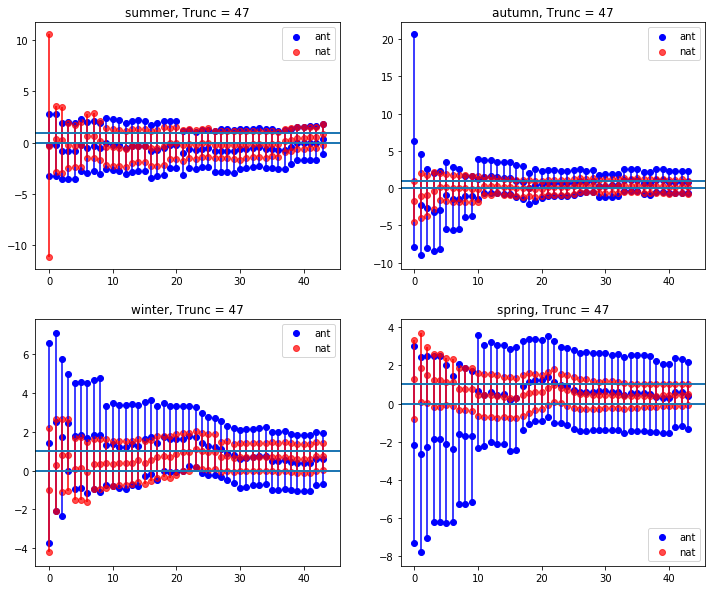

In [6]:
'''
MAIN PROGRAM

Create a seasonal plot of the regression coefficients using an array of trunctions.
The plots are saved in ~/figures/fingerprinting/scan_beta_est.
'''

fig,axs = plt.subplots(2,2, figsize=(12,10))#, sharex=True,sharey=True)
axs = axs.flatten()

seasons = ['summer','autumn','winter','spring']
for i,s in enumerate(seasons):    

    IDL.retall
    
    all_ens_mean,noise_all = get_mean_and_noise(s,'all')
    nat_ens_mean,noise_nat = get_mean_and_noise(s,'nat')
    
    data_obs = get_obs_data(s)
    
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    data_noise_1 = np.concatenate((noise_all[:25],noise_nat[:25]))
    data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))
    

    trunc = np.array([i for i in range(3,48)])
    
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    IDL.scan_resid_sumsq = []
    IDL.p_resid = []
    IDL.resid_sumsq = []
    IDL.noise_singval = []
    IDL.z_best = []

    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

    beta_est = IDL.beta_est
    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    scan_resid_sumsq = IDL.scan_resid_sumsq
    noise_singval = IDL.noise_singval
    z_best = IDL.z_best
        
    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        axs[i].scatter([j]*3,[low_1,best_1,up_1],c='blue',label='ant' if j == 0 else '')
        axs[i].scatter([j]*3,[low_2,best_2,up_2],c='red',alpha=0.7,label='nat' if j == 0 else '')

        axs[i].vlines(j,low_1,up_1,colors=['blue'])
        axs[i].vlines(j,low_2,up_2,colors=['red'])
        
        axs[i].axhline(0,-0.5,1.5)
        axs[i].axhline(1,-0.5,1.5)

    
    axs[i].set_title(s + ', Trunc = ' + str(IDL.trunc))

    axs[i].legend()
    

In [5]:
data_obs

array([1.64485363, 0.59776013, 1.28155157, ...,       -inf, 0.59776013,
       0.06270678])

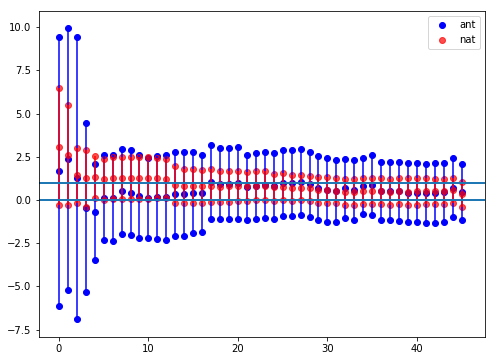

In [54]:
'''
MAIN PROGRAM

Create a seasonal plot of the regression coefficients using an array of trunctions.
The plots are saved in ~/figures/fingerprinting/scan_beta_est.
'''

fig,axs = plt.subplots(figsize=(8,6))#, sharex=True,sharey=True)

IDL.retall

all_ens_mean,noise_all = get_mean_and_noise('all','all')
nat_ens_mean,noise_nat = get_mean_and_noise('all','nat')

data_obs = get_obs_data('all')

data_scen = np.array([all_ens_mean,nat_ens_mean])

data_noise_1 = np.concatenate((noise_all[:25],noise_nat[:25]))
data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))



trunc = np.array([i for i in range(160)])

IDL.data_obs = data_obs
IDL.data_scen = data_scen
IDL.data_noise_1 = data_noise_1
IDL.data_noise_2 = data_noise_2
IDL.trunc = trunc
IDL.scan_beta_est = []
IDL.scan_p_resid = []
IDL.scan_resid_sumsq = []
IDL.p_resid = []
IDL.resid_sumsq = []
IDL.noise_singval = []
IDL.z_best = []

IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
        data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
        scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

beta_est = IDL.beta_est
scan_beta_est = IDL.scan_beta_est
scan_p_resid = IDL.scan_p_resid
scan_resid_sumsq = IDL.scan_resid_sumsq
noise_singval = IDL.noise_singval
z_best = IDL.z_best

for j in range(len(scan_beta_est)):

    beta_est = scan_beta_est[j]

    best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
    best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

    axs.scatter([j]*3,[low_1,best_1,up_1],c='blue',label='ant' if j == 0 else '')
    axs.scatter([j]*3,[low_2,best_2,up_2],c='red',alpha=0.7,label='nat' if j == 0 else '')

    axs.vlines(j,low_1,up_1,colors=['blue'])
    axs.vlines(j,low_2,up_2,colors=['red'])

    axs.axhline(0,-0.5,1.5)
    axs.axhline(1,-0.5,1.5)


#axs.set_title('All seasons, Trunc = ' + str(IDL.trunc))

axs.legend()


In [53]:
print(data_obs.shape)
print(data_scen.shape)
print(data_noise_1.shape)
print(data_noise_2.shape)

(16320,)
(2, 16320)
(50, 16320)
(50, 16320)


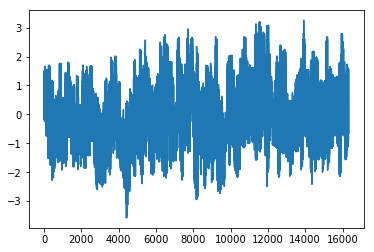

In [37]:
plt.plot(data_noise_2[4])

In [ ]:
## plt.plot(data_scen[1])

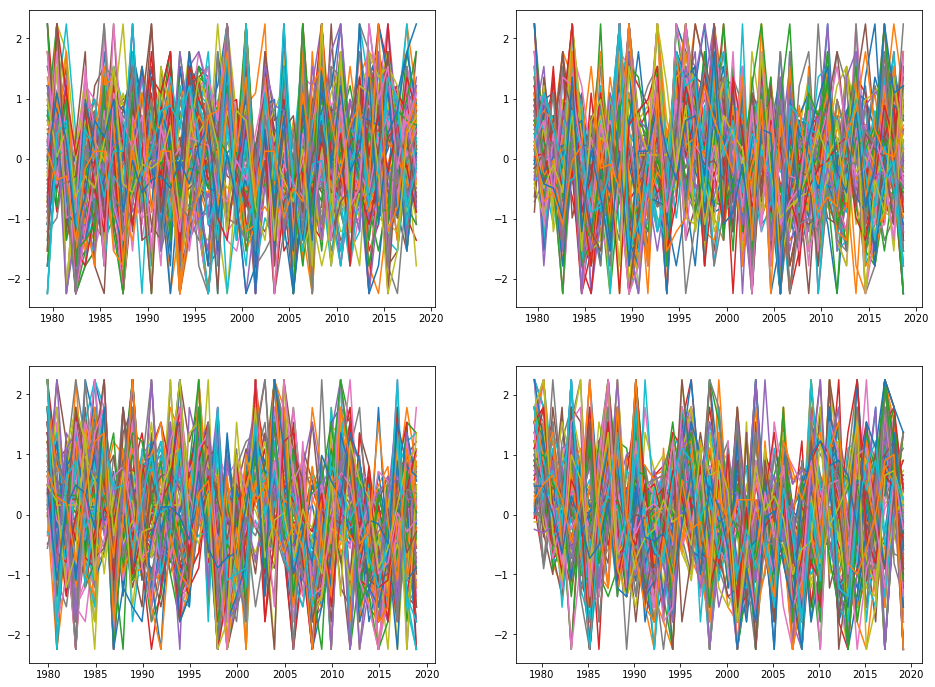

In [19]:
fig,ax = plt.subplots(2,2,figsize=(16,12))
axs = ax.flatten()
for i,season in enumerate(['winter','spring','summer','autumn']):
    df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/obs_"+season+"_gaussian.csv")
    df.date = pd.to_datetime(df.date)
    df = df.set_index('date')
    df = df['1979':'2019']

    axs[i].plot(df)


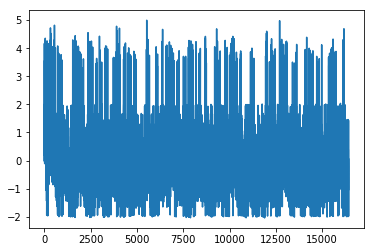

In [69]:
plt.plot(data_obs)

In [45]:
data_noise_1.shape

(50, 16320)

In [54]:
IDL.beta_est

array([[ 0.6077492 ,  0.530675  ],
       [-1.1381207 , -0.00379091],
       [ 2.353619  ,  1.0651408 ]], dtype=float32)